In [ ]:
from pathlib import Path
import os
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from pygam import LinearGAM, s

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'text.color': 'black', 'axes.labelcolor': 'black', 'axes.edgecolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black'})
ROOT = Path('/cndd/hex002/PsychEncode')
FIG = Path(os.environ.get('FIGURE6_OUTPUT_DIR', ROOT / 'BrainHydroxyDevelopment/analysis_scripts/Figures/Figure6_outputs'))
FIG.mkdir(parents=True, exist_ok=True)
METH = ROOT / 'methylation/gene_body_methylation'
CHIP = ROOT / 'ChIP'

GLU = '#4faf48'

GABA = '#397fba'

RUN_E_PERMUTATIONS = False

RUN_F_BOOTSTRAP = False

def save(fig, name):
    fig.savefig(FIG / name, bbox_inches='tight')

def zscore(x):
    return x.sub(x.mean(1), axis=0).div(x.std(1, ddof=0).replace(0, np.nan), axis=0).fillna(0)

def spline(x, y, g):
    t = SplineTransformer(n_knots=6, degree=3, include_bias=False)
    return Ridge(alpha=0.01).fit(t.fit_transform(x[:, None]), y).predict(t.transform(g[:, None]))

def dens(ax, x, y):
    q = pd.DataFrame({'x': x, 'y': y}).dropna()
    d = gaussian_kde(q.T)(q.T)
    o = np.argsort(d)
    ax.scatter(q.x.iloc[o], q.y.iloc[o], c=d[o], cmap='viridis', s=4, lw=0, rasterized=True)
    ax.axhline(0, c='.4', ls=':', lw=0.6)
    ax.axvline(0, c='.4', ls=':', lw=0.6)

## Glu age-DEG trajectories

Text(0.5, 0, 'Age (years, log-scaled)')

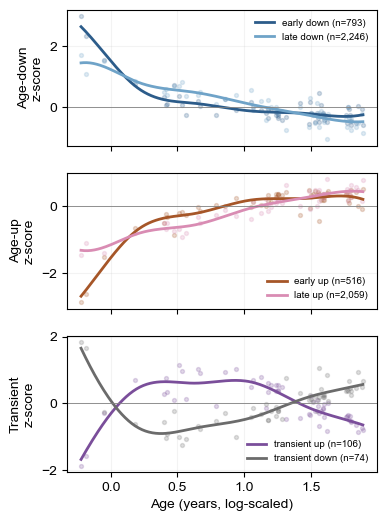

In [ ]:
g = pd.read_csv(ROOT / 'rna_seq/GLU_age_DEG_expression_dynamics_groups.tsv', sep='\t').rename(columns={'index': 'geneID'}).set_index('geneID').plot_group

e = pd.read_csv(ROOT / 'rna_seq/GLU_DE_Dream.csv', index_col=0)

meta = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS_082625.csv', index_col=0)

age = meta.loc[e.columns.intersection(meta.index), 'age'].astype(float).sort_values()

e = zscore(e[age.index])

x = np.log10(age.to_numpy() + 0.5)

grid = np.linspace(x.min(), x.max(), 250)

(fig, axs) = plt.subplots(3, 1, figsize=(4, 6), sharex=True)

groups = [(('early_down', 'late_down'), 'Age-down'), (('early_up', 'late_up'), 'Age-up'), (('transient_up', 'transient_down'), 'Transient')]

cols = ['#2C5C8A', '#6FA3C8', '#A65628', '#D98CB3', '#7A4E9A', '#6B6B6B']

for (ax, (pair, title), cc) in zip(axs, groups, [cols[:2], cols[2:4], cols[4:]]):
    for (lab, c) in zip(pair, cc):
        ids = e.index.intersection(g.index[g.eq(lab)])
        y = e.loc[ids].mean(0).to_numpy()
        ax.scatter(x, y, s=8, c=c, alpha=0.22)
        ax.plot(grid, spline(x, y, grid), c=c, lw=2, label=f"{lab.replace('_', ' ')} (n={len(ids):,})")
    ax.axhline(0, c='.5', lw=0.6)
    ax.set_ylabel(title + '\nz-score')
    ax.legend(frameon=False, fontsize=7)
    ax.grid(alpha=0.15)

axs[-1].set_xlabel('Age (years, log-scaled)')

# save(fig, 'A_trajectories.pdf')

##  PyGAM expression examples

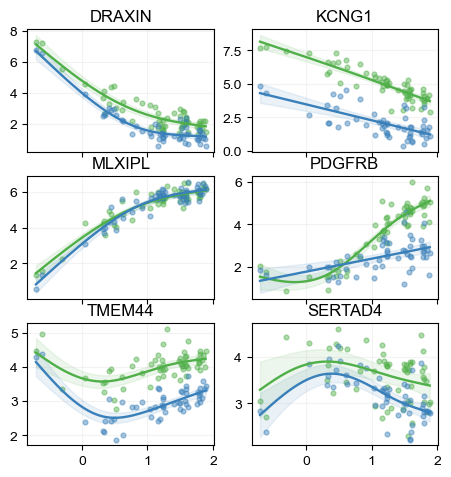

In [ ]:
ann = pd.read_csv(ROOT / 'BrainHydroxyDevelopment/analysis_scripts/Figures/data/gencode.v37.annotation.intragenic.bed.gz', sep='\t', names=['chr', 'start', 'end', 'geneID', 'strand', 'x', 'gene', 'fn'])

ids = dict(zip(ann.gene, ann.geneID))

genes = ['DRAXIN', 'KCNG1', 'MLXIPL', 'PDGFRB', 'TMEM44', 'SERTAD4']

(fig, axs) = plt.subplots(3, 2, figsize=(5.3, 5.4), sharex=True)

for (ax, gene) in zip(axs.flat, genes):
    for (ct, color) in [('GLU', GLU), ('GABA', GABA)]:
        d = pd.read_csv(ROOT / f'rna_seq/{ct}_DE_Dream.csv', index_col=0).loc[ids[gene]]
        q = pd.DataFrame({'y': d, 'age': d.index.map(meta.age), 'sex': d.index.map(meta.sex)}).dropna()
        xx = np.log10(q.age.to_numpy() + 0.1)
        ax.scatter(xx, q.y, s=12, c=color, alpha=0.45, marker='o')
        gam = LinearGAM(s(0, n_splines=8, spline_order=3)).gridsearch(xx[:, None], q.y, lam=np.logspace(0, 5, 25), progress=False)
        z = np.linspace(xx.min(), xx.max(), 300)
        ci = gam.confidence_intervals(z[:, None])
        ax.fill_between(z, ci[:, 0], ci[:, 1], color=color, alpha=0.1)
        ax.plot(z, gam.predict(z[:, None]), c=color, lw=1.7)
    ax.set_title(gene)
    ax.grid(alpha=0.15)

# save(fig, 'B_PyGAM_examples.pdf')

## RNA fold change versus gene-body hmCG log2 fold change

celltype  selected  colored  gray      rho        pvalue
     GLU     11716     3498  8218 0.379268 4.494643e-120
    GABA     11815     2390  9425 0.440063 8.999165e-114


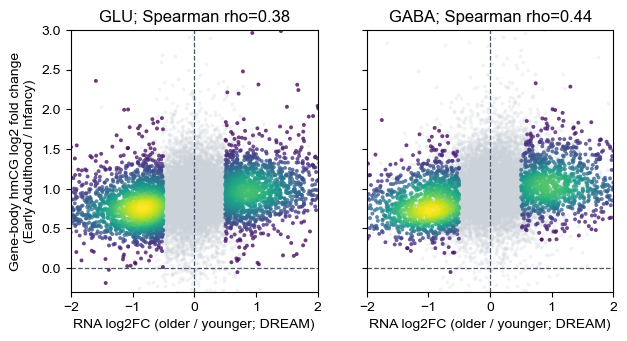

In [ ]:
import sys
import seaborn as sns

if str(CHIP) not in sys.path:
    sys.path.insert(0, str(CHIP))

from continuous_age_joint_splines import load_methylation

analysis_table = pd.read_csv(
    CHIP / 'joint_methylation_RNA_ChIP_results/epigenetic_gene_classes/'
    'downregulated_expression_length_matching/analysis_gene_table.tsv.gz',
    sep='\t',
)
scatter_trends = ['early_down', 'late_down', 'early_up', 'late_up']
long_genes = analysis_table.loc[
    analysis_table["log10_gene_length"].ge(4)
].copy()
from continuous_age_joint_splines import load_methylation

dna_qc = pd.read_csv(
    "/datasets/Public_Datasets/Dracheva_PsychEncode_development/"
    "processed/metadata_DNA_QC.tsv.gz",
    sep="\t",
)
donor_period = (
    dna_qc[["donor_ct", "period"]]
    .drop_duplicates("donor_ct")
    .set_index("donor_ct")["period"]
)
median_periods = {
    "Infancy": "Infancy",
    "Early_Childhood": "Early_Childhood",
    "Early_Adulthood": "Adulthood",
}
hmCG_median_rows = []
for celltype in ("GLU", "GABA"):
    hmCG_matrix, hmCG_metadata = load_methylation(celltype, "hmCG")
    hmCG_metadata = hmCG_metadata.copy()
    hmCG_metadata["period"] = donor_period.reindex(hmCG_metadata.index)
    medians = pd.DataFrame({
        f"hmCG_median_{label}": hmCG_matrix.loc[
            hmCG_metadata.index[hmCG_metadata["period"].eq(period)]
        ].median(axis=0)
        for label, period in median_periods.items()
    })
    medians.index = medians.index.astype(str)
    medians.index.name = "geneID"
    medians["celltype"] = celltype
    hmCG_median_rows.append(medians.reset_index())
hmCG_medians = pd.concat(hmCG_median_rows, ignore_index=True)
long_genes = long_genes.drop(
    columns=[
        column for column in hmCG_medians
        if column in long_genes and column not in {"celltype", "geneID"}
    ],
    errors="ignore",
).merge(hmCG_medians, on=["celltype", "geneID"], how="left")

# Preserve the >=10-kb trajectory-gene definition. For the gray background,
# use all persistently expressed genes that were not classified as age-DEGs;
# the matching reference called "stable_expressed" is deliberately narrower.
reference_genes = pd.read_csv(
    CHIP / (
        "joint_methylation_RNA_ChIP_results/epigenetic_gene_classes/"
        "polycomb_silent_screen/developmental_reference_group_table.tsv.gz"
    ),
    sep="\t",
)
age_trends = pd.read_csv(
    ROOT / "rna_seq/gene_trend.csv"
)[["celltype", "geneID", "trend"]]
broad_stable_genes = reference_genes.merge(
    age_trends, on=["celltype", "geneID"], how="left"
)
broad_stable_genes = broad_stable_genes.loc[
    broad_stable_genes["trend"].isna()
    & broad_stable_genes[
        ["RNA_Infancy", "RNA_EC", "RNA_Adult"]
    ].min(axis=1).gt(1)
].copy()
broad_stable_genes["comparison_group"] = "broad_stable_expressed"
broad_stable_genes = broad_stable_genes.drop(
    columns=[
        column for column in hmCG_medians
        if column in broad_stable_genes
        and column not in {"celltype", "geneID"}
    ],
    errors="ignore",
).merge(hmCG_medians, on=["celltype", "geneID"], how="left")
long_trajectory_genes = long_genes.loc[
    long_genes["comparison_group"].isin([
        "developmental_RNA_down", "developmental_RNA_up"
    ])
].copy()
scatter_genes = pd.concat(
    [long_trajectory_genes, broad_stable_genes], ignore_index=True
)
dream_all = pd.read_csv(ROOT / 'rna_seq/Dream_all_results.csv')
dream_interval = dream_all.loc[
    dream_all['comp'].eq('infancy-adulthood'),
    ['celltype', 'geneID', 'logFC']
].copy()
dream_interval['RNA_log2FC_older_vs_younger'] = -dream_interval['logFC']

selected_genes = scatter_genes.merge(
    dream_interval, on=['celltype', 'geneID'], how='inner'
)
with np.errstate(divide='ignore', invalid='ignore'):
    selected_genes['hmCG_log2FC'] = np.log2(
        selected_genes['hmCG_median_Early_Adulthood'] /
        selected_genes['hmCG_median_Infancy']
    )
selected_genes = selected_genes.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    'RNA_log2FC_older_vs_younger', 'hmCG_log2FC'
])

figure, axes = plt.subplots(1, 2, figsize=(7, 3.4), sharex=True, sharey=True)
rows = []
for axis, celltype in zip(axes, ('GLU', 'GABA')):
    selected = selected_genes.loc[selected_genes['celltype'].eq(celltype)]
    colored = selected.loc[
        selected['trend'].isin(scatter_trends) &
        selected['RNA_log2FC_older_vs_younger'].abs().ge(.5)
    ]
    gray = selected.loc[~selected.index.isin(colored.index)]
    axis.scatter(gray['RNA_log2FC_older_vs_younger'], gray['hmCG_log2FC'],
                 s=7, color='#cbd2d9', alpha=.28, linewidth=0, rasterized=True)
    x = colored['RNA_log2FC_older_vs_younger'].to_numpy(float)
    y = colored['hmCG_log2FC'].to_numpy(float)
    density = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    density = (density - density.min()) / (density.max() - density.min())
    order = np.argsort(density)
    axis.scatter(x[order], y[order], c=density[order], cmap='viridis',
                 s=8, alpha=.78, linewidth=0, rasterized=True)
    rho, pvalue = spearmanr(x, y)
    axis.axhline(0, color='#4a5568', lw=.9, ls='--')
    axis.axvline(0, color='#4a5568', lw=.9, ls='--')
    axis.set(title=f'{celltype}; Spearman rho={rho:.2f}', xlim=(-2, 2),
             ylim=(-.3, 3),
             xlabel='RNA log2FC (older / younger; DREAM)')
    rows.append((celltype, len(selected), len(colored), len(gray), rho, pvalue))

axes[0].set_ylabel('Gene-body hmCG log2 fold change\n(Early Adulthood / Infancy)')
# save(figure, 'RNA_hmCG_log2FC_scatter_infancy_to_early_adulthood_length10kb.pdf')
print(pd.DataFrame(rows, columns=[
    'celltype', 'selected', 'colored', 'gray', 'rho', 'pvalue'
]).to_string(index=False))


## RNA fold change versus total gene-body mCH log2FC

                     interval  colored_significant  gray_background       rho       pvalue
       Infancy to Adolescence                 2815            10297 -0.048175 1.057693e-02
Adolescence to Late_Adulthood                  321            10297 -0.485275 2.285167e-20


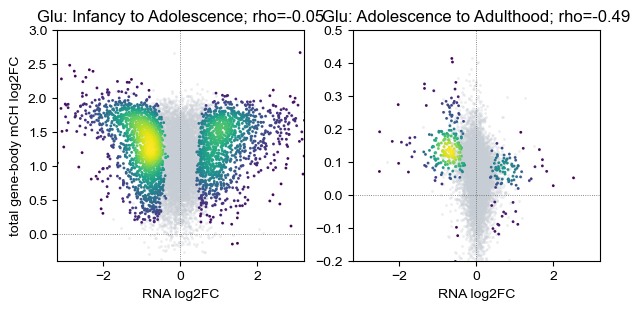

In [ ]:
import runpy

source = runpy.run_path(
    str(CHIP / 'recreate_fig6GH_RNA_mCH_scatter.py'),
    run_name='figure6_d_source',
)
legacy_namespace = source['load_legacy_namespace']()
interval_data = source['interval_data']
intervals = [('Infancy', 'Adolescence'), ('Adolescence', 'Late_Adulthood')]

figure, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=False)
panel_d_counts = []

for axis, (start, end) in zip(axes, intervals):
    background, colored, _, rho, pvalue = interval_data(
        legacy_namespace, start, end,
    )
    axis.scatter(background['RNA_log2FC'], background['mCH_log2FC'],
                 color='#C7CDD4', s=4, alpha=.35, linewidth=0, rasterized=True)
    dens(axis, colored['RNA_log2FC'], colored['mCH_log2FC'])
    display_end = 'Adulthood' if end == 'Late_Adulthood' else end
    axis.set(title=f'Glu: {start} to {display_end}; rho={rho:.2f}',
             xlim=(-3.2, 3.2),
             ylim=(-.4, 3) if start == 'Infancy' else (-.2, .5),
             xlabel='RNA log2FC')
    panel_d_counts.append((f'{start} to {end}', len(colored), len(background), rho, pvalue))

axes[0].set_ylabel('total gene-body mCH log2FC')
# save(figure, 'D_total_mCH_log2FC.pdf')
print(pd.DataFrame(panel_d_counts, columns=['interval', 'colored_significant', 'gray_background', 'rho', 'pvalue']).to_string(index=False))

## Length- and CGI-matched developmental trajectories

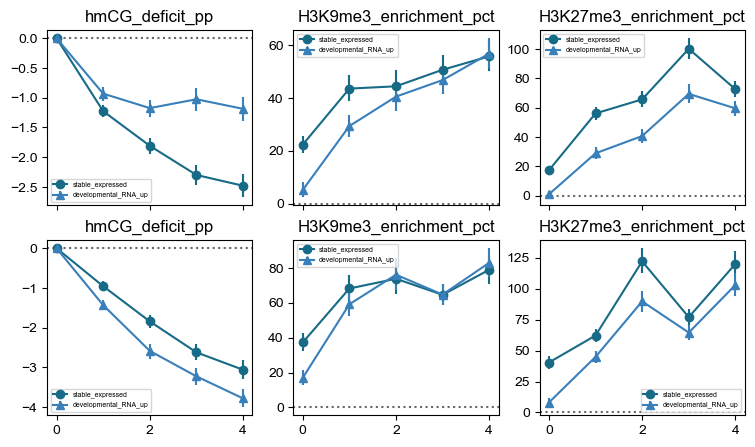

In [ ]:
f = pd.read_csv(CHIP / 'joint_methylation_RNA_ChIP_results/epigenetic_gene_classes/downregulated_expression_length_matching/compact_matched_difference_trajectories.tsv', sep='\t')

(fig, axs) = plt.subplots(2, 3, figsize=(9, 5), sharex=True)

metrics = [('hmCG_deficit_pp', 'hmCG'), ('H3K9me3_enrichment_pct', 'H3K9me3'), ('H3K27me3_enrichment_pct', 'H3K27me3')]

for (i, ct) in enumerate(['GLU', 'GABA']):
    for (j, (val, stem)) in enumerate(metrics):
        ax = axs[i, j]
        for (ref, c, m) in [('stable_expressed', '#176B87', 'o'), ('developmental_RNA_up', '#397FBA', '^')]:
            q = f[(f.celltype == ct) & (f.reference == ref)]
            x = np.arange(len(q))
            ax.errorbar(x, q[val], yerr=[q[val] - q[f'{stem}_ci_low'], q[f'{stem}_ci_high'] - q[val]], c=c, marker=m, label=ref)
        ax.axhline(0, c='.4', ls=':')
        ax.set_title(val)
        ax.legend(fontsize=5)